In [2]:
import os 
import pulp
import random
import math 
import networkx as nx 
from test_PL import fast_disjoint_balanced_heuristic
from test_PL import test_lp # SUPPRIMER CES DEUX MERDES 

class Heuristic: 

    # attributs 
    
    nb_node : int 
    nb_arcs : int  
    Dag : list[list[int]]
    R_Dag : list[list[int]]
    source : int 
    puit : int 
    TC : list[list[int]] 
    HG : list[list[int]]
    k_degen : int 

    # méthodes 

    def __init__(self,file:str): # constructeur / readfile 

        with open(file, "r") as f: 
            
            line = f.readline()
            line = line.strip().split(" ")

            self.nb_node = int(line[0])
            self.nb_arcs = int(line[1])
            self.k_degen = int(line[2])

            self.Dag = [[] for _ in range(self.nb_node)]
            self.R_Dag = [[] for _ in range(self.nb_node)]

            for _ in range(self.nb_arcs):

                line = f.readline()
                line = line.strip().split(" ")

                start = int(line[0])
                end = int(line[1])

                self.Dag[start].append(end)
                self.R_Dag[end].append(start)

        self.source = 0
        self.puit = self.nb_node-1 
        
        # calcule des structures 
        self.compute_TC()
        # self.compute_HG()
        # self.compute_degenerascy()


    def display_Dag(self): 

        for i in range(len(self.Dag)): 
            print(i," -> { ", end="")
            for u in self.Dag[i]: 
                print(u, " ", end="")
            print("}")


    def display_R_Dag(self): 

        for i in range(len(self.R_Dag)): 
            print(i," -> { ", end="")
            for u in self.R_Dag[i]: 
                print(u, " ", end="")
            print("}")

    # calcule la transitive closure du dag 
    # pr rappel : TC[u][v] = 1 si u -> v 
    def compute_TC(self): 

        self.TC = [[0 for _ in range(self.nb_node)]
                   for _ in range(self.nb_node)]
        
        for u in range(self.nb_node): # on copie la matrice d'adjacence 
            self.TC[u][u] = 1 # diagonale toujours à 1 
            for neigh in self.Dag[u]: 
                self.TC[u][neigh] = 1

        for k in range(self.nb_node): 
            for i in range(self.nb_node): 
                for j in range(self.nb_node): 

                    if self.TC[i][k] and self.TC[k][j]: 
                        self.TC[i][j] = 1 


    # calcule le graphe de co-comparabilité
    # s'occupe lui-même de calculer la transitive closure 
    def compute_HG(self): 

        self.HG = [[] for _ in range(self.nb_node)]
        
        for u in range(self.nb_node): 
            for v in range(u+1,self.nb_node): 

                if self.TC[u][v] == 0 and self.TC[v][u] == 0: 
                    self.HG[u].append(v) 
                    self.HG[v].append(u)


    # calcule la k-degen de HG 
    def compute_degenerascy(self): 

        # calcul des degrés de HG 
        degree_to_nodes = [[] for _ in range(self.nb_node)]
        node_to_degree = [0 for _ in range(self.nb_node)]

        for u in range(self.nb_node): # pr chq sommet -> calcul son degré initial
            d_u = len(self.HG[u])
            node_to_degree[u] = d_u 
            degree_to_nodes[d_u].append(u)
        
        max_deg = 0 # on mémorisera dedans le maximum des + petits degrés rencontrés 
        node_removed = 0 

        while node_removed < self.nb_node: 

            # trouver le sommet de degré le plus petit 
            for deg in range(len(degree_to_nodes)): # pr chq degre dans l'ordre croissant 
                if degree_to_nodes[deg]: # si c'est pas vide, on a enfin trouvé un sommet 
                    
                    node = degree_to_nodes[deg][0] # on récupère le premier
                    if deg > max_deg: # si il est plus grand que le max alors rencontré 
                        max_deg = deg 

                    # remove node 
                    node_to_degree[node] = -1 # par défaut 
                    degree_to_nodes[deg].remove(node)
                    node_removed += 1 
                    
                    for neigh in self.HG[node]: 
                        neigh_deg = node_to_degree[neigh] # récup le degré actuel du voisin 
                        if neigh_deg == -1 : continue # si on l'a déjà retiré -> ignore 
                        node_to_degree[neigh] -= 1 # sinon décrémenter 
                        degree_to_nodes[neigh_deg].remove(neigh) # on l'enlève 
                        degree_to_nodes[neigh_deg-1].append(neigh) # on l'ajoute 

                    break # on va au prochain 

        self.k_degen = max_deg        


    # ordre_size définit a quelle taille de l'ordre on s'arrete. 
    # si ordre_size == -1, alors on considère qu'on recherch un ordre entier 
    # sinon si ordre_size < nb_node, on cherche à générer un ordre partiel
    def trouve_ordre_topo(self,ordre_size:int): 

        if ordre_size == -1:
            ordre_size = self.nb_node

        elif ordre_size > self.nb_node: 
            print("ERROR ordre size")
            return -1
        
        elif ordre_size < -1: 
            print("ERROR ordre size")
            return -1

        # on set up les degrés entrants dans le dag 
        node_degrees = [[] for _ in range(self.nb_node)]
        zero_in_deg = [] # mémorise les node de deg = 0
        
        for u in range(self.nb_node): # pr chq node
            in_deg_u = len(self.R_Dag[u]) 
            node_degrees[u] = in_deg_u
            if in_deg_u == 0:
                zero_in_deg.append(u)

        ordre_topo = []
        while len(ordre_topo) < ordre_size: 
            
            next_node = random.choice(zero_in_deg) # récup noeud de deg 0
            zero_in_deg.remove(next_node) # retire des noeuds possibles
            ordre_topo.append(next_node) # ajt a l'ordre 

            for neigh in self.Dag[next_node]: 
                node_degrees[neigh] -= 1 # retire un degré entrant 
                if node_degrees[neigh] == 0: 
                    zero_in_deg.append(neigh)
            
        return ordre_topo 
    
    # vérifie une solution 
    # fonctionne aussi bien sur les ordres complets
    # que sur des ordres topo partiellements construits
    def checker(self, ordre_topo):

        # on associe a chq node sa position dans l'ordre 
        node_to_ordre = [-1 for _ in range(self.nb_node)]
        
        for i in range(len(ordre_topo)): 
            node_to_ordre[ordre_topo[i]] = i

        valid_order = True 

        for u in range(self.nb_node): 
            
            u_pos = node_to_ordre[u]
            if u_pos == -1: continue 
            if not valid_order: break
            
            for neigh in self.Dag[u]: 

                neigh_pos = node_to_ordre[neigh]
                if neigh_pos == -1: continue 

                if u_pos > neigh_pos: 
                    print("ERROR")
                    valid_order = False 
                    break 

        if valid_order: 
            print("checker ok")
        

    # Cette fonction calcule la valeur pour DSC 
    # d'un ordre topo partiel. Cet ordre topo partiel 
    # correspond en fait exactement à un cut-set 
    def compute_partial_DSC(self,cut_set:list): 
        
        node_to_ordre = [-1 for _ in range(self.nb_node)] 
        
        for i in range(len(cut_set)): # calcul de node_to_ordre
            node_to_ordre[cut_set[i]] = i
        
        obj_value = 0 
        
        for i in range(len(cut_set)-1): # pr chq ordre 
            for phi_u in range(i+1): # pr tt u tq phi(u) <= i

                u = cut_set[phi_u]

                if u == self.source:
                    continue # ignore source

                for neigh in self.Dag[u]: # pr chq voisin 
                    
                    if neigh == self.puit: 
                        continue # ignore puit 

                    # si neigh est après l'ordre i 
                    if node_to_ordre[neigh] > i or node_to_ordre[neigh] == -1: # -1 signifie hors cut-set 
                        obj_value += 1 
                        break 
                    
        return obj_value


    # calcule la valeur d'un ordre topologique. L'ordre doit être complet
    def compute_DSC_value(self,ordre_topo:list): 

        obj_value = 0

        if len(ordre_topo) < self.nb_node: 
            print("ordre incomplet")
            return -1
        
        # on associe a chq node sa position dans l'ordre 
        node_to_ordre = [-1 for _ in range(self.nb_node)]

        for i in range(len(ordre_topo)): 
            node_to_ordre[ordre_topo[i]] = i
        
        for i in range(self.nb_node-1): 
            for phi_u in range(i+1): # pour tout u tq phi(u) <= i

                u = ordre_topo[phi_u] # récup le noeud 
                
                if u == self.source: # ignorer la source 
                    continue  
        
                for neigh in self.Dag[u]: 

                    if(neigh == self.puit): 
                        continue # ignorer le puit 

                    if node_to_ordre[neigh] > i: 
                        obj_value += 1
                        break # go next u

        return obj_value
                        
    # compute borne inf sur un ordre topologique 
    # partiellement construit (un cut-set en gros)
    def compute_LB1(self, ordre_topo:list): 
        
        hors_cut_set = [u for u in range(self.nb_node) if u not in ordre_topo] 
        partial_DSC_value = self.compute_partial_DSC(ordre_topo) # calcul de v(S)
        
        # compute value idéale sur le hors_cut_set 
        hcs_value = 0
        for u in hors_cut_set: # on va considérer que ses voisins sont calés à gauche juste après u 
            if u == self.source: continue # ignore s 
            hcs_value += len(self.Dag[u]) 
            if self.puit in self.Dag[u]: # ignorer t  
                hcs_value -= 1 

        # compute participation des sommets dans cut-set 
        # en fonction du nombre de leur succ direct hors cut-set 
        ics_value = 0
        for u in ordre_topo: 
            if u == self.source: continue # ignore s
            nb_succ_hcs = 0
            for neigh in self.Dag[u]: # pr chq voisin 
                if neigh == self.puit: continue # ignore t 
                if neigh in hors_cut_set: # si il est pas ds cut-set 
                    nb_succ_hcs += 1 # alors u participera au moins a nb_succ_hcs coupes 
            ics_value += nb_succ_hcs

        print("LB1 pure : ", hcs_value + ics_value)

        return hcs_value + partial_DSC_value + ics_value

    
    def compute_LB2(self, cut_set:list): 

        hors_cut_set = [u for u in range(self.nb_node) if u not in cut_set] 
        partial_DSC_value = self.compute_partial_DSC(cut_set) # calcul de v(S)

        # compute participation des sommets dans cut-set 
        # en fonction du nombre de leur succ direct hors cut-set 
        ics_value = 0
        for u in cut_set: 
            if u == self.source: continue 
            for w in hors_cut_set: 
                if w == self.puit: continue # inutile de continuer ici 

                for v in self.Dag[u]: 

                    if v == self.puit: continue 
                    if self.TC[w][v]: 
                        ics_value += 1 
                        break 

        # calcul de la participation des sommets dans V-S (façon L2)

        hcs_value = 0
        for u in hors_cut_set: 
            if u == self.source: continue # ignore s 

            for w in hors_cut_set: 
                if w == u or w == self.puit: continue 

                if self.TC[u][w]: # si w est sur un chemin orienté depuis u 
                    for v in self.Dag[u]: 
                        if v == self.puit: continue 
                        if self.TC[w][v]: # si w est sur un chemin entre u et v (v voisin de u)
                            hcs_value += 1 
                            break 

        print("hcs_value : ", hcs_value)
        print("ics_value : ", ics_value)
        print("LB2 pure : ", ics_value + hcs_value)
        return ics_value + hcs_value + partial_DSC_value
    

    def compute_LB3(self, cut_set): 

        hors_cut_set = [u for u in range(self.nb_node) if u not in cut_set] 
        partial_DSC_value = self.compute_partial_DSC(cut_set) # calcul de v(S)

        # compute participation des sommets dans cut-set 
        # grâce a un LP   

        # calcule les ensembles de blocages
        
        ensembles_blocage = [[] for _ in range(len(cut_set))]
        
        for i, u in enumerate(cut_set): 
            if u == self.source: continue 
            for w in hors_cut_set: 
                if w == self.puit: continue # inutile de continuer ici 

                for v in self.Dag[u]: 

                    if v == self.puit: continue 
                    if self.TC[w][v]: 
                        ensembles_blocage[i].append(w)
                        break  
                        
        ensembles_blocage = [x for x in ensembles_blocage if x != []] # on retire les blocages vides 
        print(ensembles_blocage)
        print(len(ensembles_blocage))
        ics_value = fast_disjoint_balanced_heuristic(ensembles_blocage)

        # calcul de la participation des sommets dans V-S (façon L2)

        hcs_value = 0
        for u in hors_cut_set: 
            if u == self.source: continue # ignore s 

            for w in hors_cut_set: 
                if w == u or w == self.puit: continue 

                if self.TC[u][w]: # si w est sur un chemin orienté depuis u 
                    for v in self.Dag[u]: 
                        if v == self.puit: continue 
                        if self.TC[w][v]: # si w est sur un chemin entre u et v (v voisin de u)
                            hcs_value += 1 
                            break 
        
        print("LB3 pure : ", ics_value + hcs_value)
        return partial_DSC_value + hcs_value + ics_value


    def affiche_Dag_sans_puit_source(self): 

        nb_arc_pur = 0
        for u, succ in enumerate(self.Dag): 
            if u == self.source: # si c'est la source
                continue  
            for v in succ: 
                if v == self.puit: 
                    continue 
                print(u," -> ", v)
                nb_arc_pur += 1 
        print("nombre d'arcs pur dans le dag : ", nb_arc_pur)

        
# FIN CLASSE IMPLÉ 

def lance_test(inst:str, taux_completion:float): 
    """
    Permet de tester le calcul des bornes inférieures sur un ordre topologique généré aléatoirement
    -> inst est l'instance considérée 
    -> taux_completion est le pourcentage que contiendra l'ordre topologique partiel. Par exemple, 
    si il vaut 0.5, alors on va générer un ordre topologique valide de taille n/2. 
    """
    pb = Heuristic(inst)
    taille_partielle = int(pb.nb_node*taux_completion)

    ordre_topo = pb.trouve_ordre_topo(taille_partielle)
    pb.checker(ordre_topo)

    partial_DSC_value = pb.compute_partial_DSC(ordre_topo)

    LB1 = pb.compute_LB1(ordre_topo)
    LB2 = pb.compute_LB2(ordre_topo)
    

    print("LB1 = ", LB1)
    print("LB2 = ", LB2)
    print("pdscv : ", partial_DSC_value)

    # return partial_DSC_value, LB1, LB2 

# écrit les informations dans un fichier texte au format suivant : 
# INSTANCE / RATIO / PARTIAL DSC VAL / LB1 / LB2 
def write_infos(path_to_write:str): 

    instances = [f for f in sorted(os.listdir("../inst")) if not f.startswith(".")]
    with open(path_to_write, "w") as f: 
        for inst in instances: 
            print(inst)
            ratios = [0.25,0.5,0.75]
            for ratio in ratios: 

                pdscv, L1, L2 = lance_test(f"../inst/{inst}", ratio)
                f.write(f"{inst} {ratio} {pdscv} {L1} {L2}\n")


In [23]:

# simple fonction qui recherche les résultats calculés pour SAA 
# pour l'instance renseignée en argument 
def cherche_inst_results(inst:str): 

    with open("../results/data_SAA_LB.txt", "r") as f:
        for line in f: 
            line = line.strip().split(" ")
            if line[0] != inst: continue 
            print("SAA value : ", line[1])
            break

inst_name = "100_n_34_k_3_ID.txt"
lance_test(f"../instances/k_variations/{inst_name}",0.7)
cherche_inst_results(inst_name)

checker ok
LB1 pure :  235
hcs_value :  44
ics_value :  645
LB2 pure :  689
LB1 =  2568
LB2 =  3022
pdscv :  2333
SAA value :  3625


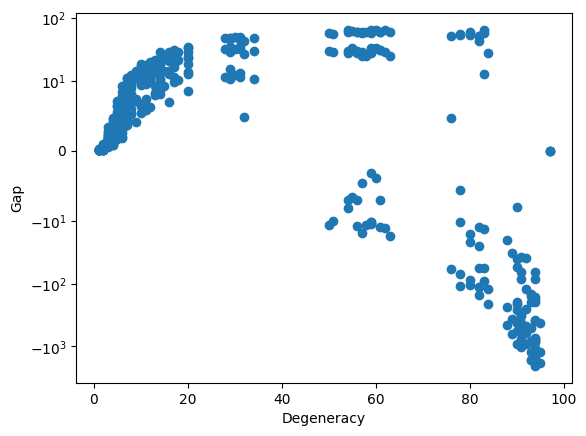

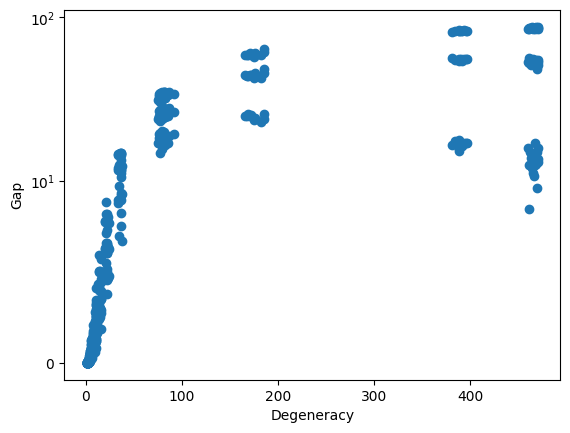

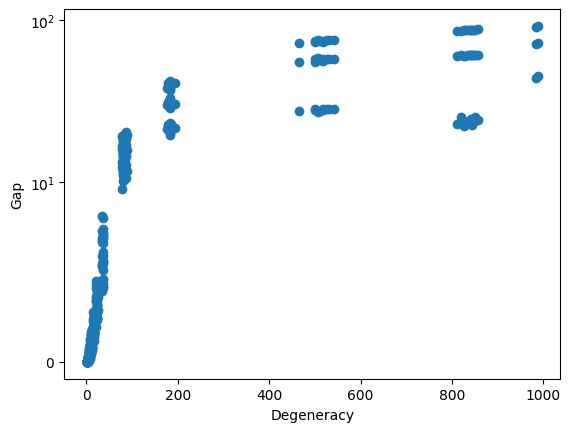

In [4]:
# QUELQUES TRUCS DE STATISTIQUES 

import matplotlib.pyplot as plt 

# calcule le gap moyen en pourcentage pour chaque ratio 
# de complétion d'ordre topologique partiel {0.25, 0.50, 0.75}
def compute_average_gap_per_ratio(path:str): 
    # path est le chemin vers le txt contenant les informations
    with open(path, "r") as f: 

        av_gap_0_25 = 0
        av_gap_0_50 = 0
        av_gap_0_75 = 0

        nb_0_25 = 0
        nb_0_50 = 0
        nb_0_75 = 0

        for line in f: 

            line = line.strip().split(" ")
            
            if line[2] == '0.25': 
                av_gap_0_25 += float(line[6])
                nb_0_25 += 1
            elif line[2] == '0.5': 
                av_gap_0_50 += float(line[6])
                nb_0_50 += 1
            else: 
                av_gap_0_75 += float(line[6])
                nb_0_75 += 1
        
    av_gap_0_25 = av_gap_0_25/nb_0_25
    av_gap_0_50 = av_gap_0_50/nb_0_50
    av_gap_0_75 = av_gap_0_75/nb_0_75

    print("ratio 0.25 -> ", av_gap_0_25)
    print("ratio 0.50 -> ", av_gap_0_50)
    print("ratio 0.75 -> ", av_gap_0_75)


def count_nb_elaging_time(path:str):
    """
    Cette fonction lit le fichier txt qui regroupe des infos telles que 
    SAA_value, LB1, LB2, gap LB2-SAA_Value (par instance & ratio)
    renvoie le nombre de fois où on aurait pu élaguer (cad nb de fois où
    SAA_val < LB2) pour chaque ratio. Renvoie aussi les instances concernées 
    """

    instances_concernees = []
    with open(path, "r") as f: 

        nb_0_25 = 0
        nb_0_50 = 0 # pr compter le nb de fois qu'un ratio a un gap < 0
        nb_0_75 = 0

        for line in f: 

            line = line.strip().split(" ")

            if float(line[6]) > 0: 
                continue 
            
            print(line)

            if line[0] not in instances_concernees: 
                instances_concernees.append(line[0])

            if line[2] == '0.25': 
                nb_0_25 += 1
            elif line[2] == '0.5':
                nb_0_50 += 1
            elif line[2] == '0.75': 
                nb_0_75 += 1

    print("ratio 0.25 -> ", nb_0_25)
    print("ratio 0.50 -> ", nb_0_50)
    print("ratio 0.75 -> ", nb_0_75)
    print("instances admettant un élagage : ", instances_concernees)


def relation_gap_degen(wanted_n:int, path:str): 
    """
    Prend le fichier txt de données
    le parse et dessine un nuage de point montrant la relation
    entre gap et degeneracy pour n = wanted_n
    """

    gaps = []
    degens = []

    with open(path, "r") as f: 
        
        for line in f: 

            line = line.strip().split(" ")
            inst_name = line[0]
            inst_name = inst_name.split("_")
            
            # inst_name est décomposé 

            n = int(inst_name[0]) # inst_name[0] = taille du graphe
            k = int(inst_name[2]) # inst_name[2] = degeneracy
            gap = float(line[6])

            if n != wanted_n:
                continue 

            gaps.append(gap)
            degens.append(k)

    # affichage du nuage de points 
    plt.scatter(degens, gaps)
    plt.xlabel("Degeneracy")
    plt.ylabel("Gap")
    plt.yscale("symlog", linthresh=10)
    plt.show()

relation_gap_degen(100, "../results/data_SAA_LB.txt")
relation_gap_degen(500, "../results/data_SAA_LB.txt")           
relation_gap_degen(1000, "../results/data_SAA_LB.txt")
